---
title: "Poisson Equation"
format: 
    html: 
        toc: true
execute: 
  enabled: true
bibliography: "../../references.bib"
jupyter: python3
---

In this example, we illustrate how we can build a DIRT to perform (approximate) amortised inference. The key idea is to build a DIRT approximation to the joint density of the observations and parameters; then, as a consequence of the triangular structure of the DIRT mapping, we can sample from the DIRT approximation to the posterior of the parameters, for any realisation of the observations, in real time. For further details on the ideas behind amortised inference, see @Cui2023.

# Problem Setup

We consider the Poisson equation defined in domain $\Omega := (0, 1) \times (0, 1)$, with boundary denoted by $\partial \Omega$; that is,

$$
  \nabla \cdot (\kappa(\boldsymbol{x}) \nabla u(\boldsymbol{x})) = 0, \quad \boldsymbol{x} \in \Omega.
$$

This equation can be used to model the flow of fluid in a porous medium, in which case $u(\boldsymbol{x})$ denotes the fluid pressure and $\kappa(\boldsymbol{x})$ denotes the diffusion coefficient. Following @Cui2025, we impose the boundary conditions

$$
\begin{align*}
    u(\boldsymbol{x}) &= 1 + \frac{x_{1}}{2}, \qquad &&\boldsymbol{x} \in \partial\Omega_{\mathrm{L}}, \\
    u(\boldsymbol{x}) &= -\sin(2\pi x_{2}) - 1, \qquad &&\boldsymbol{x} \in \partial\Omega_{\mathrm{R}}, \\
    (\kappa(\boldsymbol{x}) u(\boldsymbol{x})) \cdot \boldsymbol{n} &= 0, \qquad &&\boldsymbol{x} \in \partial\Omega_{\mathrm{T}} \cup \partial\Omega_{\mathrm{B}}.
\end{align*}
$$

In the above, $\partial\Omega_{\mathrm{L}}$, $\partial\Omega_{\mathrm{R}}$, $\partial\Omega_{\mathrm{T}}$, and $\partial\Omega_{\mathrm{B}}$ denote the left, right, top and bottom boundaries respectively, and $\boldsymbol{n}$ denotes the outward-facing normal vector on the boundary.

## Prior Density

We endow the logarithm of the unknown diffusion coefficient with a process convolution prior; that is,

$$
    \log(\kappa(\boldsymbol{x})) = \log(\bar{\kappa}(\boldsymbol{x})) + \sum_{i=1}^{d} \xi^{(i)} \exp\left(-\frac{1}{2r^{2}}\left\lVert\boldsymbol{x} - \boldsymbol{x}^{(i)}\right\rVert^{2}\right),
$$

where $d=9$, $\log(\bar{\kappa}(\boldsymbol{x})) = 0$, $r=1/20$, the coefficients $\{\xi^{(i)}\}_{i=1}^{d}$ are independent and follow the unit Gaussian distribution, and the centres of the kernel functions, $\{\boldsymbol{x}^{(i)}\}_{i=1}^{d}$, are equispaced over the domain (see @fig-prior-samples).

# Implementation in $\texttt{deep\_tensor}$

In [1]:
import math

from matplotlib import pyplot as plt
import torch
from torch import Tensor
from typing import Tuple

import deep_tensor as dt

from examples.poisson.setup import setup_poisson_problem
from examples.poisson.solver import vec2func
from examples.plotting import (
    add_arrows, 
    pairplot, 
    plot_dl_function, 
    set_plot_style
)
from examples.poisson.pcn import run_pcn

In [2]:
torch.manual_seed(0)
set_plot_style()

experiment_name = "kl_pca_sd_0.15"

## Set up model and prior

In [3]:
prior, model = setup_poisson_problem(rom=False, num_kl=10)

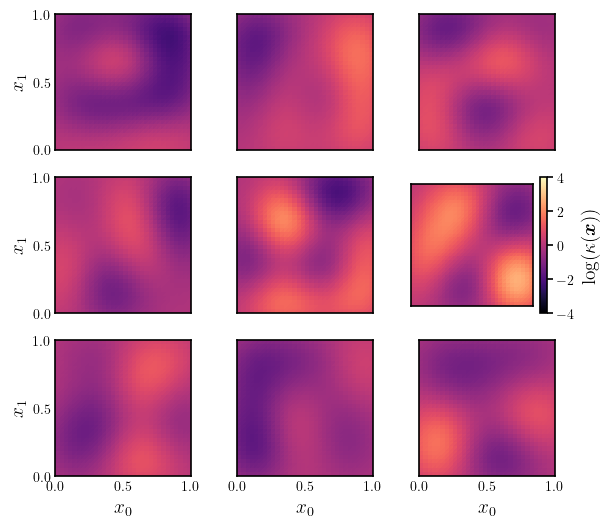

In [4]:
fig, axes = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(6.65, 6.0))

prior_samples = [
    prior.transform(sample)
    for sample in prior.sample(n=9)
]

for i, ax in enumerate(axes.flat):
    
    plot_dl_function(
        fig, ax, 
        vec2func(prior_samples[i], model.Vh), 
        plot_cbar=(i==5), 
        cbar_label=r"$\log(\kappa(\bm{x}))$", 
        cmap="magma",
        vmin=-4.0, 
        vmax=4.0
    )

    # ax.scatter(*prior.ss.T, c="k", marker="x")

    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.tick_params(axis="both", which="both", length=0)
    ax.set_xlabel("$x_{0}$" if i > 5 else None)
    ax.set_ylabel("$x_{1}$" if (i % 3) == 0 else None)

## Generate observations and reparametrise

In [5]:
sd_noise = 0.15

Generate some samples of the observations (to be used for dimension reduction)

In [6]:
num_solves = 5000

x_samples = prior.sample(num_solves)
logk_samples = torch.vstack([prior.transform(x_i) for x_i in x_samples])
noise_samples = sd_noise * torch.randn((num_solves, model.num_obs))

y_samples = torch.vstack([
    model.observe(model.solve(logk_samples[i]))
    for i in range(num_solves)
])

y_obs_samples = y_samples + noise_samples


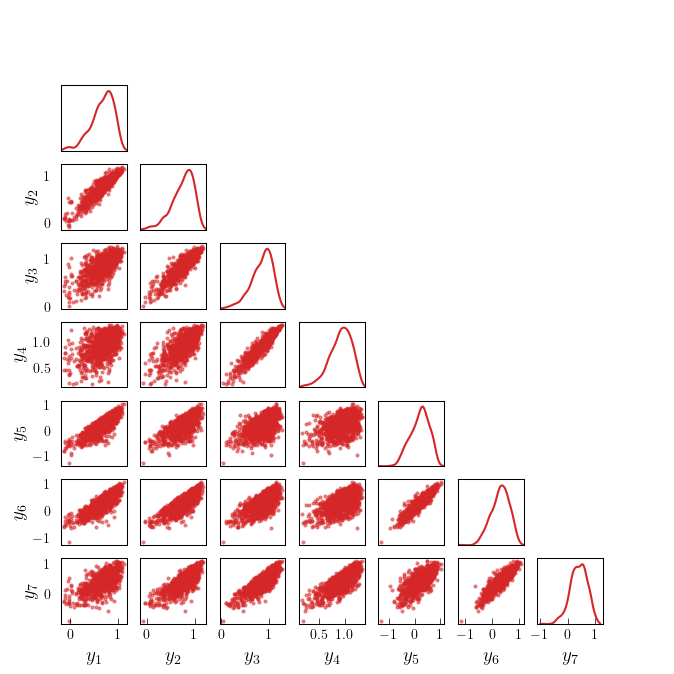

In [7]:
num_ys = 7
labels = [r"$y_{"+f"{i+1}"+r"}$" for i in range(num_ys)]
pairplot(y_samples[:1000, :num_ys], labels=labels)
# plt.savefig("plots/pairplot_ys.pdf")

Define functions to compute a reduced basis for the observations using PCA

In [8]:
def compute_pca(samples: Tensor, eps=0.01) -> Tuple[Tensor, Tensor]:
    """Computes a reduced basis for the data using PCA."""
    
    mean = samples.mean(dim=0)
    cov = samples.T.cov()

    vals, vecs = torch.linalg.eigh(cov)

    energies = vals.flip(dims=(0,)).cumsum(dim=0)
    energies /= energies[-1].clone()
    num_components = torch.sum(energies < 1.0 - eps) + 1

    # Flip the order of the vectors, so that the components with 
    # largest energy are towards the ends of the ordering
    vecs = vecs[:, -num_components:].flip(dims=(1,))
    vals = vals[-num_components:].flip(dims=(0,))

    return mean, vecs

def pca_weights(ys: Tensor, mu: Tensor, V: Tensor) -> Tensor:
    """Returns the PCA weights corresponding to sets of observations."""
    return (ys - mu) @ V

def pca_project(us: Tensor, mu: Tensor, V: Tensor) -> Tensor:
    """Returns the observations corresponding to sets of PCA weights."""
    return mu + us @ V.T

In [9]:
mu, V = compute_pca(y_samples)

u_obs_samples = pca_weights(y_obs_samples, mu, V)
joint_samples = torch.hstack((u_obs_samples, x_samples))

print(f"Number of components retained: {V.shape[1]}.")

Number of components retained: 6.


Define preconditioning mapping between the reference and a Gaussian fit to the (joint) samples of the observations and parameters

In [10]:
mean_joint = joint_samples.mean(dim=0)
cov_joint = joint_samples.T.cov()
dim_joint = mean_joint.numel()

inflation_factor = 1.0
cov_joint *= inflation_factor

domain = dt.BoundedDomain([-5.0, 5.0])
reference = dt.GaussianReference(domain)
preconditioner = dt.GaussianMapping(mean_joint, cov_joint, reference)

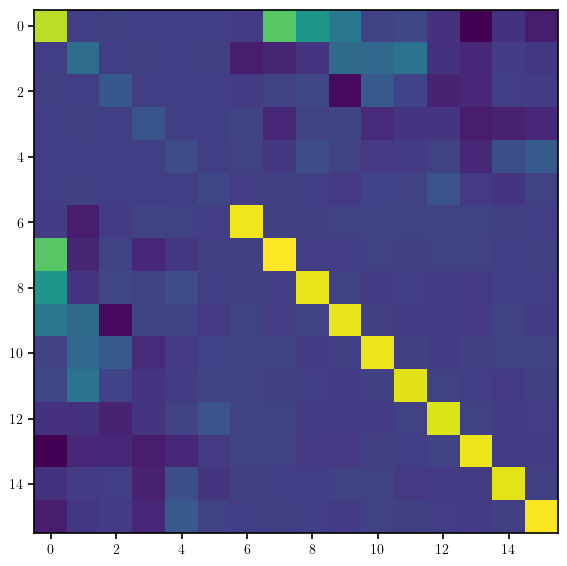

In [11]:
import matplotlib.pyplot as plt

plt.imshow(cov_joint)

Alternative preconditioning mapping

In [12]:
# mean_joint = joint_samples.mean(dim=0)
# sd_joint = joint_samples.std(dim=0)

# bounds = torch.vstack([
#     mean_joint - 5.0 * sd_joint,
#     mean_joint + 5.0 * sd_joint
# ]).T

# domain = dt.BoundedDomain([-3.0, 3.0])
# reference = dt.GaussianReference(domain)
# preconditioner = dt.UniformMapping(bounds, reference)

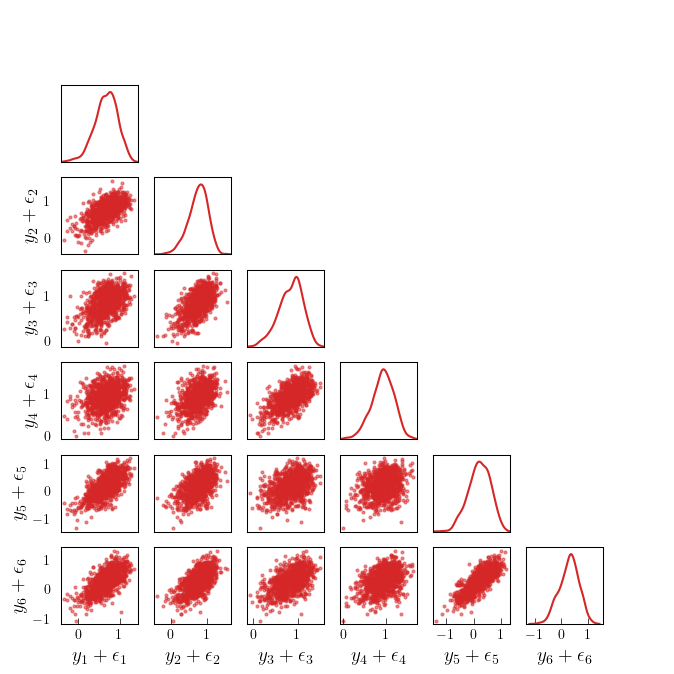

In [13]:
num_ys = 6
labels = [r"$y_{"+f"{i+1}"+r"} + \epsilon_{"+f"{i+1}"+r"}$" for i in range(num_ys)]
pairplot(y_obs_samples[:1000, :num_ys], labels=labels)
# plt.savefig(f"plots/{experiment_name}_pairplot_yobs.pdf")

Plot comparison between the actual joint distribution and the preconditioner

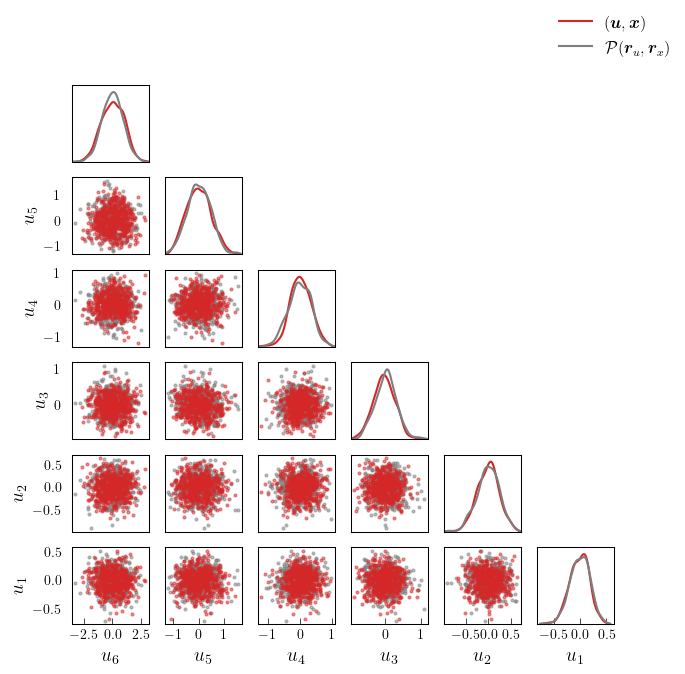

In [14]:
num_samples = 500
rs = reference.random(num_samples, dim_joint)

num_components = V.shape[1]
num_plot = 6
min_plot = 0

labels_y = [r"$u_{"+f"{i+1}"+r"}$" for i in range(num_components-min_plot)]
labels_x = [r"$x_{"+f"{i+1}"+r"}$" for i in range(min_plot+num_plot-num_components)]
labels = list(reversed(labels_y)) + labels_x  # type: ignore

xs_gauss = preconditioner.Q(rs)[0]

pairplot(joint_samples[:num_samples, :6], xs_gauss[:, :6], labels=labels, x_label=r"$(\bm{u}, \bm{x})$", y_label=r"$\mathcal{P}(\bm{r}_{u}, \bm{r}_{x})$")
# plt.savefig(f"plots/{experiment_name}_pairplot_joint.pdf")

## DIRT construction 

In [15]:
def neglogjoint(uxs: Tensor) -> Tensor:
    """Evaluates the potential function of (a quantity proportional to) 
    the joint density of the observations and parameters.
    """

    us, xs = uxs[:, :-prior.dim], uxs[:, -prior.dim:]
    ys_obs = pca_project(us, mu, V)

    ys = torch.vstack([
        model.observe(model.solve(prior.transform(x_i)))
        for x_i in xs
    ])
    
    neglogliks = (0.5 / sd_noise**2) * (ys_obs - ys).square().sum(dim=1)
    neglogpris = 0.5 * xs.square().sum(dim=1)

    return neglogliks + neglogpris

target_func = dt.TargetFunc(neglogjoint)

In [16]:
basis = dt.Lagrange1(num_elems=30)
tt_options = dt.TTOptions(tt_method="fixed_rank", init_rank=10, max_als=1, verbose=2)
tt = dt.TT(tt_options)
ftt = dt.FTT(basis, tt)
# eftt_options = dt.EFTTOptions(tol_svd=1e-3, num_snapshots=80)
# ftt = dt.EFTT(basis, tt, options=eftt_options)

We then define the sequence of bridging densities that will be approximated at each layer of the DIRT construction.

In [17]:
# good
betas = 10.0 ** torch.linspace(-1.0, 0.0, 6)
bridge = dt.Tempering(betas)
# bridge = dt.SingleLayer()

In [18]:
# best so far (DHell=0.2680)
# betas1 = 10.0 ** torch.linspace(-3.0, -1.0, 5)
# betas2 = 10.0 ** torch.linspace(-0.5, 0.0, 6)

# betas1 = 10.0 ** torch.linspace(-3.0, -1.0, 5)
# betas2 = 10.0 ** torch.linspace(-0.8, 0.0, 10)
# betas = torch.cat((betas1, betas2))
# bridge = dt.Tempering(betas)

Finally, we construct the DIRT approximation to the joint density.

In [ ]:
dirt_options = dt.DIRTOptions(defensive=0.0)
dirt = dt.DIRT(target_func, preconditioner, ftt, bridge, options=dirt_options)

[DIRT] Iter:  1 | Cum. Fevals: 1.00e+03 | Cum. Time: 4.60e+00 s | Beta: 0.1000 | DHell: 0.0000 | ESS: 0.9194
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |      45020 |       10 |       1.00e+00 |        1.00e+00 | 2.47e+00
[ALS]  ALS complete.
[ALS]  Maximum TT rank: 10.
[DIRT] Iter:  2 | Cum. Fevals: 4.70e+04 | Cum. Time: 2.36e+02 s | Beta: 0.1585 | DHell: 0.1382 | ESS: 0.8361
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |      45020 |       10 |       2.23e-01 |        7.75e-02 | 7.31e-01
[ALS]  ALS complete.
[ALS]  Maximum TT rank: 10.
[DIRT] Iter:  3 | Cum. Fevals: 9.30e+04 | Cum. Time: 4.33e+02 s | Beta: 0.2512 | DHell: 0.1421 | ESS: 0.8218
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |      45020 |       10 |       7.58e-02 |        3.41e-02 | 8.26e-01
[ALS]  ALS complete.
[ALS]  Maximum TT rank: 10.
[DIRT] Iter:  4 | Cum. Fevals: 1.3

## Amortised Inference

In [ ]:
# Generate some observations
x = prior.sample(n=1)
logk = prior.transform(x.flatten())
y_obs = model.observe(model.solve(logk)) + sd_noise * torch.randn(model.num_obs)

# Generate a set of samples from the reference
num_conditional_samples = 5000
rs = dirt.reference.random(n=num_conditional_samples, d=prior.dim)

# Transform the samples such that they are distributed according to the 
# DIRT approximation to the posterior
u_obs = pca_weights(y_obs, mu, V)
xs_cond, neglogfxs_cond_dirt = dirt.eval_cirt(u_obs, rs)

In [ ]:
def neglogpost(xs: Tensor, ys_obs: Tensor) -> Tensor:
    """Evaluates the potential function associated with (a function 
    proportional to) the posterior for a given dataset.
    """

    ys = torch.vstack([
        model.observe(model.solve(prior.transform(x_i)))
        for x_i in xs
    ])
    
    neglogliks = (0.5 / sd_noise**2) * (ys_obs - ys).square().sum(dim=1)
    neglogpris = 0.5 * xs.square().sum(dim=1)

    return neglogliks + neglogpris

neglogfxs_cond_true = neglogpost(xs_cond, y_obs)

res = dt.run_independence_sampler(
    xs_cond, 
    neglogfxs_cond_dirt, 
    neglogfxs_cond_true
)

In [ ]:
print(res.xs[0].mean(dim=0))
print(res.xs[0].std(dim=0))

# print(f"Acceptance rate: {res.acceptance_rate:.2f}.")
# print(f"Mean IACT: {res.iacts.mean():.2f}.")
# print(f"Max IACT: {res.iacts.max():.2f}.")

In [ ]:
num_test_samples = 20

xs_test = prior.sample(num_test_samples)
logks_test = torch.vstack([prior.transform(x_i) for x_i in xs_test])
noise_test = sd_noise * torch.randn((num_test_samples, model.num_obs))
ys_test = torch.vstack([
    model.observe(model.solve(logks_test[i])) + noise_test[i]
    for i in range(num_test_samples)
])
us_test = pca_weights(ys_test, mu, V)

acceptance_rates = torch.zeros((num_test_samples,))
mean_iacts = torch.zeros((num_test_samples,))
max_iacts = torch.zeros((num_test_samples,))
dhells = torch.zeros((num_test_samples,))

rs = dirt.reference.random(n=5000, d=prior.dim)

In [ ]:
for i in range(num_test_samples):

    xs_cond, neglogfxs_cond_dirt = dirt.eval_cirt(us_test[i], rs)
    neglogfxs_cond_true = neglogpost(xs_cond, ys_test[i])

    res = dt.run_independence_sampler(
        xs_cond, 
        neglogfxs_cond_dirt, 
        neglogfxs_cond_true
    )

    dhell = dt.compute_f_divergence(-neglogfxs_cond_dirt, -neglogfxs_cond_true).sqrt()
    plt.plot(res.xs[0, :, 0])
    # plt.plot(neglogfxs_cond_dirt)
    plt.show()

    acceptance_rates[i] = res.acceptance_rates[0]
    mean_iacts[i] = res.iacts.mean()
    max_iacts[i] = res.iacts.max()
    dhells[i] = dhell

    print(f"{res.iacts.mean() = }")
    print(f"{res.iacts.max() = }")

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))

axes[0].hist(acceptance_rates)
axes[1].hist(mean_iacts)
axes[2].hist(dhells)
axes[3].hist(dhells.log())

axes[0].set_xlabel("Acceptance Rate")
axes[1].set_xlabel("Mean IACT")
axes[2].set_xlabel(r"$\mathcal{D}_{\mathrm{H}}$")
axes[3].set_xlabel(r"log($\mathcal{D}_{\mathrm{H}}$)")

axes[0].set_ylabel("Count")

for ax in axes.flat:
    ax.set_box_aspect(1)
    add_arrows(ax)

# plt.savefig(f"plots/{experiment_name}_amortised_stats.pdf")

In [ ]:
dhells

In [ ]:
# Choose a particular instance of the measured data
y_test_k = ys_test[-2]
u_test_k = us_test[-2]

def neglogpost_k(xs: Tensor) -> Tensor:
    return neglogpost(xs, y_test_k)

## MCMC

In [ ]:
num_chains = 8

In [ ]:
x0s = torch.zeros((num_chains, prior.dim))
xs, neglogfxs, acceptance_rates, iacts = run_pcn(neglogpost_k, x0s, dt_=math.exp(-1.0), num_steps=5000)

In [ ]:
mean_iact = iacts.mean()
mean_sd_xs = xs.mean(dim=1).std(dim=0).mean()

print(f"{mean_iact = }")
print(f"{mean_sd_xs = }")

In [ ]:
# Compute the mean of each of the parameters in each chain, then compute the variance over the chains, then compute the average over all parameters.

In [ ]:
r0s = torch.zeros((num_chains, prior.dim))

In [ ]:
kernel = dt.pCNKernel(neglogpost_k, dirt, u_test_k, dt=10.0)
mcmc = dt.MCMC(kernel)

res_anticorrelated = mcmc.run(r0s, num_steps=5000)

In [ ]:
mean_iact = res_anticorrelated.iacts.mean()
mean_sd_xs = res_anticorrelated.xs.mean(dim=1).std(dim=0).mean()

print(f"{mean_iact = }")
print(f"{mean_sd_xs = }")

In [ ]:
kernel = dt.pCNKernel(neglogpost_k, dirt, u_test_k, dt=2.0)
mcmc = dt.MCMC(kernel)

res_uncorrelated = mcmc.run(r0s, num_steps=5000)

In [ ]:
mean_iact = res_uncorrelated.iacts.mean()
mean_sd_xs = res_uncorrelated.xs.mean(dim=1).std(dim=0).mean()

print(f"{mean_iact = }")
print(f"{mean_sd_xs = }")